# Bike Sharing Demand Prediction

## 1. Problem Definition

The goal of this project is to build a machine learning regression model
that predicts the total number of bike rentals (`cnt`) using historical
bike sharing data and relevant temporal, environmental, and weather-related
features.

## 2. Import Libraries

The following libraries are used for data manipulation, visualization, preprocessing, model training, evaluation, and hyperparameter tuning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3. Load Dataset

The hourly bike sharing dataset is used because it contains the `hr` feature, which allows us to analyze how bike rental demand changes throughout the day.

In [2]:
df = pd.read_csv("../data/hour.csv")

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 4. Understand the Dataset

Before performing exploratory analysis, we inspect the structure, data types, and basic characteristics of the dataset.

### 4.1 Dataset Shape

In [4]:
df.shape

(17379, 17)

### 4.2 Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


### 4.3 Descriptive Statistics

In [6]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Average Bike Rentals by Hour

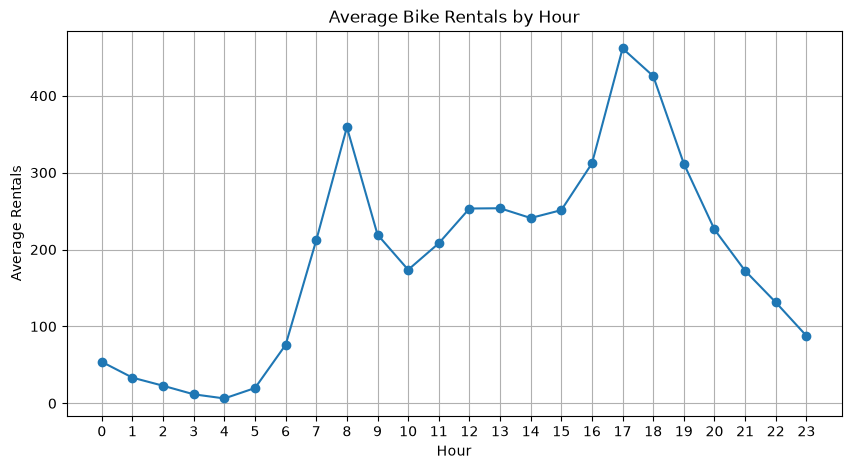

In [7]:
hourly_demand = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand.index, hourly_demand.values, marker="o")

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.xticks(range(24))
plt.grid(True)
plt.show()

### Temperature vs Bike Rental Demand

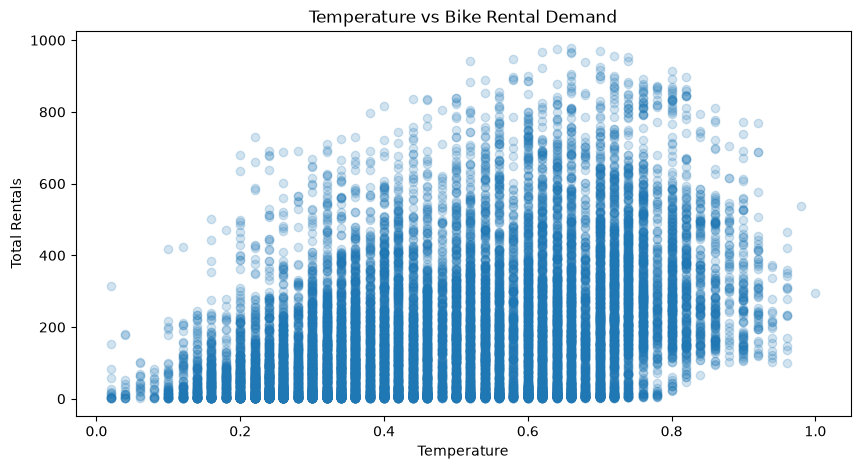

In [8]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["temp"],
    df["cnt"],
    alpha=0.2
)

plt.title("Temperature vs Bike Rental Demand")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.show()

### Average Bike Rentals by Weather Condition

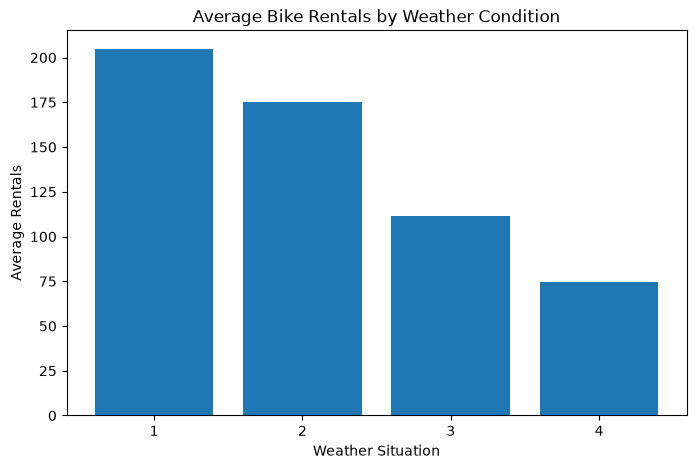

In [9]:
weather_demand = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    weather_demand.index.astype(str),
    weather_demand.values
)

plt.title("Average Bike Rentals by Weather Condition")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")

plt.show()

## 5. Feature Selection

The target variable is `cnt`, representing the total number of bike rentals.

The columns `casual` and `registered` are excluded because they directly contribute to the target variable and would cause data leakage.

The `instant` column is an index and does not provide meaningful predictive information. The original date column `dteday` is also excluded because its temporal information is represented through derived features such as year, month, weekday, and hour.

In [10]:
target = "cnt"

features_to_drop = [
    "instant",
    "dteday",
    "casual",
    "registered"
]

X = df.drop(columns=features_to_drop + [target])
y = df[target]

In [11]:
X.shape, y.shape

((17379, 12), (17379,))

## 6. Feature Engineering

The dataset already provides useful temporal and environmental features such as hour, month, year, weekday, temperature, humidity, and weather conditions.

Therefore, no additional manually engineered features are required at this stage.

In [12]:
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

In [13]:
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

## 7. Preprocessing

Categorical features are encoded using One-Hot Encoding because their numerical labels do not represent a meaningful order.

Numerical features are passed through without transformation.

A `ColumnTransformer` is used to apply these transformations consistently.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

## 8. Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13903, 12), (3476, 12), (13903,), (3476,))

## 9. Baseline Model

In [17]:
baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

In [18]:
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_prediction)
)
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 140.07983470382123
Baseline RMSE: 178.03491698930847
Baseline R²: -0.0009796282323204508


## 10. Decision Tree

In [19]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("decision_tree", DecisionTreeRegressor(random_state=42))
    ]
)

In [20]:
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('decision_tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['season','yr','mnth',...,'atemp','hum','windspeed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [21]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

In [22]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R²:", dt_r2)

Decision Tree MAE: 40.05739355581128
Decision Tree RMSE: 66.29087368433147
Decision Tree R²: 0.8612214479976585


## 11. Random Forest

In [23]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("random_forest", RandomForestRegressor(
            random_state=42
        ))
    ]
)

In [24]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['season','yr','mnth',...,'atemp','hum','windspeed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [25]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [26]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 29.80089935749904
Random Forest RMSE: 47.874593510661555
Random Forest R²: 0.9276189189694087


## 12. Gradient Boosting

In [27]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("gradient_boosting", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

In [28]:
gradient_boosting_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('gradient_boosting', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['season','yr','mnth',...,'atemp','hum','windspeed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with 

In [29]:
y_pred_gb = gradient_boosting_pipeline.predict(X_test)

In [30]:
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 58.003441448744276
Gradient Boosting RMSE: 79.89598771187828
Gradient Boosting R²: 0.7984119396198285


## 13. Model Comparison

In [31]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R²": [
        baseline_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

model_results

,Model,MAE,RMSE,R²
0,Baseline,140.079835,178.034917,-0.000980
1,Decision Tree,40.057394,66.290874,0.861221
2,Random Forest,29.800899,47.874594,0.927619
3,Gradient Boosting,58.003441,79.895988,0.798412


## 14. Cross-Validation

In [32]:
tscv = TimeSeriesSplit(n_splits=5)

In [33]:
cv_mae_scores = []

for fold, (train_index, val_index) in enumerate(
    tscv.split(X_train), start=1
):
    X_cv_train = X_train.iloc[train_index]
    X_cv_val = X_train.iloc[val_index]

    y_cv_train = y_train.iloc[train_index]
    y_cv_val = y_train.iloc[val_index]

    random_forest_pipeline.fit(X_cv_train, y_cv_train)

    y_cv_pred = random_forest_pipeline.predict(X_cv_val)

    fold_mae = mean_absolute_error(y_cv_val, y_cv_pred)

    cv_mae_scores.append(fold_mae)

    print(
        f"Fold {fold}: "
        f"Train = {len(train_index)}, "
        f"Validation = {len(val_index)}"
    )

Fold 1: Train = 2318, Validation = 2317
Fold 2: Train = 4635, Validation = 2317
Fold 3: Train = 6952, Validation = 2317
Fold 4: Train = 9269, Validation = 2317
Fold 5: Train = 11586, Validation = 2317


In [34]:
cv_mae_scores

[51.518289310890516,
 41.778618903754854,
 37.33814415192059,
 35.3321273917422,
 31.624148971371028]

In [35]:
cv_mean_mae = np.mean(cv_mae_scores)

print("CV Mean MAE:", cv_mean_mae)

CV Mean MAE: 39.518265745935835


## 15. Hyperparameter Tuning

### 15.1 Random Forest

In [36]:
rf_param_grid = {
    "random_forest__n_estimators": [100, 200],
    "random_forest__max_depth": [None, 20]
}

In [37]:
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [38]:
rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'random_forest__max_depth': [None, 20], 'random_forest__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, def

In [39]:
print("Best Parameters:")
print(rf_grid_search.best_params_)

print("Best CV MAE:")
print(-rf_grid_search.best_score_)

Best Parameters:
{'random_forest__max_depth': None, 'random_forest__n_estimators': 200}
Best CV MAE:
32.49213688980685


In [40]:
tuned_rf_pipeline = rf_grid_search.best_estimator_

y_pred_tuned_rf = tuned_rf_pipeline.predict(X_test)

tuned_rf_mae = mean_absolute_error(y_test, y_pred_tuned_rf)
tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned_rf)
)
tuned_rf_r2 = r2_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest MAE:", tuned_rf_mae)
print("Tuned Random Forest RMSE:", tuned_rf_rmse)
print("Tuned Random Forest R²:", tuned_rf_r2)

Tuned Random Forest MAE: 29.571299026658995
Tuned Random Forest RMSE: 47.44788931703572
Tuned Random Forest R²: 0.928903427884743


### 15.2 Gradient Boosting

In [41]:
gb_param_grid = {
    "gradient_boosting__n_estimators": [100, 200],
    "gradient_boosting__learning_rate": [0.1],
    "gradient_boosting__max_depth": [3]
}

In [42]:
gb_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [43]:
gb_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradient_boosting__learning_rate': [0.1], 'gradient_boosting__max_depth': [3], 'gradient_boosting__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for calla

In [44]:
print("Best Parameters:")
print(gb_grid_search.best_params_)

print("Best CV MAE:")
print(-gb_grid_search.best_score_)

Best Parameters:
{'gradient_boosting__learning_rate': 0.1, 'gradient_boosting__max_depth': 3, 'gradient_boosting__n_estimators': 200}
Best CV MAE:
48.43741345108864


In [45]:
tuned_gb_pipeline = gb_grid_search.best_estimator_

y_pred_tuned_gb = tuned_gb_pipeline.predict(X_test)

tuned_gb_mae = mean_absolute_error(y_test, y_pred_tuned_gb)
tuned_gb_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned_gb)
)
tuned_gb_r2 = r2_score(y_test, y_pred_tuned_gb)

print("Tuned Gradient Boosting MAE:", tuned_gb_mae)
print("Tuned Gradient Boosting RMSE:", tuned_gb_rmse)
print("Tuned Gradient Boosting R²:", tuned_gb_r2)

Tuned Gradient Boosting MAE: 46.85463127425836
Tuned Gradient Boosting RMSE: 66.3703882635261
Tuned Gradient Boosting R²: 0.8608883241260901


## 16. Final Model Comparison

In [46]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        tuned_rf_mae,
        tuned_gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        tuned_rf_rmse,
        tuned_gb_rmse
    ],
    "R²": [
        baseline_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        tuned_rf_r2,
        tuned_gb_r2
    ]
})

final_results

,Model,MAE,RMSE,R²
0,Baseline,140.079835,178.034917,-0.000980
1,Decision Tree,40.057394,66.290874,0.861221
2,Random Forest,29.800899,47.874594,0.927619
3,Gradient Boosting,58.003441,79.895988,0.798412
4,Tuned Random Forest,29.571299,47.447889,0.928903
5,Tuned Gradient Boosting,46.854631,66.370388,0.860888


## 17. Feature Importance

### Feature Importance of the Final Model

In [47]:
final_rf_model = tuned_rf_pipeline.named_steps["random_forest"]

final_feature_names = (
    tuned_rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

final_feature_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

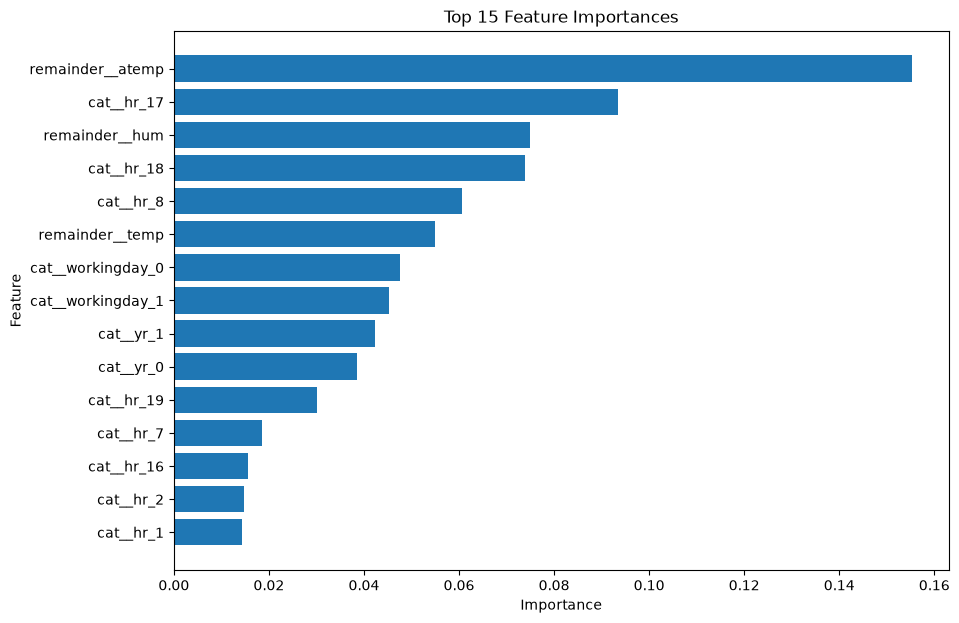

In [48]:
top_features = final_feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [49]:
final_feature_importance["Original_Feature"] = (
    final_feature_importance["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
    .str.replace(r"_\d+$", "", regex=True)
)

final_grouped_importance = (
    final_feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

### Final Feature Importance by Original Feature

In [50]:
final_grouped_importance.columns = [
    "Feature",
    "Importance"
]

final_grouped_importance

,Feature,Importance
0,hr,0.449062
1,atemp,0.155293
2,workingday,0.092677
3,yr,0.080958
4,hum,0.074833
5,temp,0.054958
6,season,0.026360
7,mnth,0.019882
8,weekday,0.017473
9,weathersit,0.014229


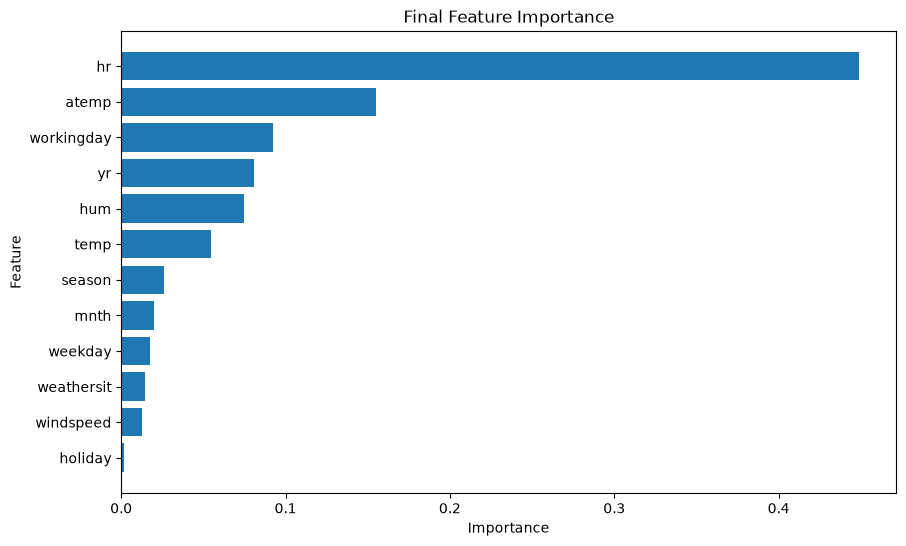

In [51]:
plot_importance = final_grouped_importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"]
)

plt.title("Final Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 18. Final Model Selection

Random Forest achieved the best overall performance among the evaluated models and was selected as the final model.

In [52]:
final_model = tuned_rf_pipeline

## 19. Business Insights

### 1. Time and Working Day

Hour is the most important predictive feature. Rental demand varies substantially throughout the day, and the demand pattern differs between working and non-working days.

### 2. Season and Weather

Bike rental demand varies across seasons, with the highest average demand observed in Season 3. Poorer weather conditions are associated with lower average rental demand.

### 3. Temperature and Humidity

Temperature shows a generally positive but non-linear relationship with rental demand. Humidity has a less straightforward relationship with demand but still contributes to the model's predictions.

## 20. Conclusion

Several regression models were evaluated for predicting total bike rental demand.

Random Forest achieved the strongest overall performance and was selected as the final model. Hyperparameter tuning provided a small improvement over the initial Random Forest model.

The final model demonstrates that temporal factors, especially hour, along with temperature and working-day information, are important for predicting bike rental demand.